<a href="https://colab.research.google.com/github/Akarshak78/SatChangeNet/blob/main/satellite_remote_sensing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
train_path = "/content/drive/MyDrive/project_sattlelite/train"
val_path = "/content/drive/MyDrive/project_sattlelite/val"
test_path = "/content/drive/MyDrive/project_sattlelite/test"

In [3]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class SatelliteChangeDataset(Dataset):
    def __init__(self, data_path, transform=None, img_size=256):
        self.data_path   = data_path
        self.transform   = transform
        self.img_size    = img_size
        self.image_names = sorted(os.listdir(os.path.join(data_path, 'A')))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        name = self.image_names[idx]

        img_A = Image.open(os.path.join(self.data_path, 'A', name)).convert('RGB')
        img_B = Image.open(os.path.join(self.data_path, 'B', name)).convert('RGB')
        label = Image.open(os.path.join(self.data_path, 'label', name)).convert('L')

        # ✅ Resize label to match image size
        label = label.resize((self.img_size, self.img_size), Image.NEAREST)

        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)

        label = torch.tensor(np.array(label) / 255.0, dtype=torch.float32)
        label = label.unsqueeze(0)  # [1, H, W]

        return img_A, img_B, label

In [4]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        if f.endswith((".pth", ".pt", ".ckpt")):
            print(os.path.join(root, f))

In [6]:
IMG_SIZE = 256

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = SatelliteChangeDataset(train_path, transform=transform, img_size=IMG_SIZE)
val_dataset   = SatelliteChangeDataset(val_path,   transform=transform, img_size=IMG_SIZE)
test_dataset  = SatelliteChangeDataset(test_path,  transform=transform, img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=2)

# ✅ Verify shapes match
img_A, img_B, label = next(iter(train_loader))
print(f"img_A : {img_A.shape}")   # Expected: [8, 3, 256, 256]
print(f"img_B : {img_B.shape}")   # Expected: [8, 3, 256, 256]
print(f"label : {label.shape}")   # Expected: [8, 1, 256, 256] ✅
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

img_A : torch.Size([8, 3, 256, 256])
img_B : torch.Size([8, 3, 256, 256])
label : torch.Size([8, 1, 256, 256])
Train: 445 | Val: 64 | Test: 128


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Device          : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.11.0+cu128
CUDA available  : True
Device          : Tesla T4


In [8]:
class SiameseEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super(SiameseEncoder, self).__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)

        # Extract feature layers (multi-scale features)
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1,
                                     resnet.relu, resnet.maxpool)  # 64ch
        self.layer1 = resnet.layer1   # 64ch
        self.layer2 = resnet.layer2   # 128ch
        self.layer3 = resnet.layer3   # 256ch
        self.layer4 = resnet.layer4   # 512ch

    def forward(self, x):
        f0 = self.layer0(x)    # [B, 64,  64, 64]
        f1 = self.layer1(f0)   # [B, 64,  64, 64]
        f2 = self.layer2(f1)   # [B, 128, 32, 32]
        f3 = self.layer3(f2)   # [B, 256, 16, 16]
        f4 = self.layer4(f3)   # [B, 512,  8,  8]
        return f1, f2, f3, f4

# ✅ Quick test
encoder = SiameseEncoder(pretrained=True).cuda()
dummy   = torch.randn(2, 3, 256, 256).cuda()
f1, f2, f3, f4 = encoder(dummy)
print(f"f1 : {f1.shape}")   # [2, 64,  64, 64]
print(f"f2 : {f2.shape}")   # [2, 128, 32, 32]
print(f"f3 : {f3.shape}")   # [2, 256, 16, 16]
print(f"f4 : {f4.shape}")   # [2, 512,  8,  8]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s]


f1 : torch.Size([2, 64, 64, 64])
f2 : torch.Size([2, 128, 32, 32])
f3 : torch.Size([2, 256, 16, 16])
f4 : torch.Size([2, 512, 8, 8])


In [9]:
class TemporalAttentionModule(nn.Module):
    """
    Computes attention between T1 and T2 features.
    Highlights changed regions, suppresses unchanged ones.
    """
    def __init__(self, in_channels):
        super(TemporalAttentionModule, self).__init__()

        self.query_conv = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key_conv   = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value_conv = nn.Conv2d(in_channels, in_channels,      kernel_size=1)

        self.gamma = nn.Parameter(torch.zeros(1))  # learnable scale
        self.softmax = nn.Softmax(dim=-1)

        # Channel attention gate
        self.channel_gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(in_channels * 2, in_channels),
            nn.ReLU(),
            nn.Linear(in_channels, in_channels),
            nn.Sigmoid()
        )

    def forward(self, feat_A, feat_B):
        B, C, H, W = feat_A.shape

        # --- Spatial Attention ---
        Q = self.query_conv(feat_A).view(B, -1, H * W).permute(0, 2, 1)  # [B, HW, C//8]
        K = self.key_conv(feat_B).view(B, -1, H * W)                      # [B, C//8, HW]

        attention = self.softmax(torch.bmm(Q, K))                          # [B, HW, HW]

        V = self.value_conv(feat_B).view(B, -1, H * W)                    # [B, C, HW]
        spatial_out = torch.bmm(V, attention.permute(0, 2, 1))
        spatial_out = spatial_out.view(B, C, H, W)
        spatial_out = self.gamma * spatial_out + feat_A

        # --- Channel Attention ---
        combined = torch.cat([feat_A, feat_B], dim=1)                      # [B, 2C, H, W]
        channel_weights = self.channel_gate(combined).view(B, C, 1, 1)    # [B, C, 1, 1]

        # --- Difference with Attention ---
        diff = torch.abs(spatial_out - feat_B)
        attended_diff = diff * channel_weights

        return attended_diff

# ✅ Quick test
attn   = TemporalAttentionModule(512).cuda()
dummy  = torch.randn(2, 512, 8, 8).cuda()
out    = attn(dummy, dummy)
print(f"Attention output : {out.shape}")  # [2, 512, 8, 8]

Attention output : torch.Size([2, 512, 8, 8])


In [10]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DecoderBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

# ✅ Quick test
dec   = DecoderBlock(512, 256).cuda()
dummy = torch.randn(2, 512, 16, 16).cuda()
out   = dec(dummy)
print(f"Decoder output : {out.shape}")  # [2, 256, 16, 16]

Decoder output : torch.Size([2, 256, 16, 16])


In [11]:
class SatChangeNet(nn.Module):
    def __init__(self, pretrained=True):
        super(SatChangeNet, self).__init__()

        # Shared Siamese Encoder
        self.encoder = SiameseEncoder(pretrained=pretrained)

        # Temporal Attention at each scale
        self.attn4 = TemporalAttentionModule(512)
        self.attn3 = TemporalAttentionModule(256)
        self.attn2 = TemporalAttentionModule(128)
        self.attn1 = TemporalAttentionModule(64)

        # Decoder
        self.dec4 = DecoderBlock(512,       256)
        self.dec3 = DecoderBlock(256 + 256, 128)
        self.dec2 = DecoderBlock(128 + 128, 64)
        self.dec1 = DecoderBlock(64  + 64,  32)

        # Final change map head
        self.head = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1,  kernel_size=1),
        )

    def forward(self, img_A, img_B):
        # Encode both images with shared weights
        f1_A, f2_A, f3_A, f4_A = self.encoder(img_A)
        f1_B, f2_B, f3_B, f4_B = self.encoder(img_B)

        # Temporal attention at each scale
        d4 = self.attn4(f4_A, f4_B)  # [B, 512,  8,  8]
        d3 = self.attn3(f3_A, f3_B)  # [B, 256, 16, 16]
        d2 = self.attn2(f2_A, f2_B)  # [B, 128, 32, 32]
        d1 = self.attn1(f1_A, f1_B)  # [B,  64, 64, 64]

        # Decode with skip connections
        x = self.dec4(d4)             # [B, 256,  8,  8]

        x = F.interpolate(x, size=d3.shape[2:], mode='bilinear', align_corners=True)
        x = self.dec3(torch.cat([x, d3], dim=1))  # [B, 128, 16, 16]

        x = F.interpolate(x, size=d2.shape[2:], mode='bilinear', align_corners=True)
        x = self.dec2(torch.cat([x, d2], dim=1))  # [B, 64, 32, 32]

        x = F.interpolate(x, size=d1.shape[2:], mode='bilinear', align_corners=True)
        x = self.dec1(torch.cat([x, d1], dim=1))  # [B, 32, 64, 64]

        # Upsample to original size + predict
        x = F.interpolate(x, size=(256, 256), mode='bilinear', align_corners=True)
        out = self.head(x)            # [B, 1, 256, 256]

        return out

# ✅ Quick test
model  = SatChangeNet(pretrained=False).cuda()
dummy_A = torch.randn(2, 3, 256, 256).cuda()
dummy_B = torch.randn(2, 3, 256, 256).cuda()
out    = model(dummy_A, dummy_B)
print(f"Parameters  : {sum(p.numel() for p in model.parameters()):,}")
print(f"Output shape: {out.shape}")   # [2, 1, 256, 256] ✅

Parameters  : 15,403,989
Output shape: torch.Size([2, 1, 256, 256])


In [12]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super(BCEDiceLoss, self).__init__()
        self.bce_weight  = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()

    def dice_loss(self, pred, target, smooth=1e-6):
        pred   = torch.sigmoid(pred)
        pred   = pred.view(-1)
        target = target.view(-1)

        intersection = (pred * target).sum()
        dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
        return 1 - dice

    def forward(self, pred, target):
        bce  = self.bce(pred, target)
        dice = self.dice_loss(pred, target)
        return self.bce_weight * bce + self.dice_weight * dice

# ✅ Quick test
criterion = BCEDiceLoss()
dummy_pred   = torch.randn(2, 1, 256, 256)
dummy_target = torch.randint(0, 2, (2, 1, 256, 256)).float()
loss = criterion(dummy_pred, dummy_target)
print(f"Loss value : {loss.item():.4f}")  # any positive number ✅

Loss value : 0.6523


In [13]:
def evaluate_metrics(pred_logits, targets, threshold=0.5):
    """
    Returns: F1, IoU, Precision, Recall, OA (Overall Accuracy)
    """
    preds   = (torch.sigmoid(pred_logits) > threshold).float()
    preds   = preds.view(-1).cpu()
    targets = targets.view(-1).cpu()

    TP = ((preds == 1) & (targets == 1)).sum().float()
    TN = ((preds == 0) & (targets == 0)).sum().float()
    FP = ((preds == 1) & (targets == 0)).sum().float()
    FN = ((preds == 0) & (targets == 1)).sum().float()

    precision = TP / (TP + FP + 1e-6)
    recall    = TP / (TP + FN + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    iou       = TP / (TP + FP + FN + 1e-6)
    oa        = (TP + TN) / (TP + TN + FP + FN + 1e-6)

    return {
        'F1':        f1.item(),
        'IoU':       iou.item(),
        'Precision': precision.item(),
        'Recall':    recall.item(),
        'OA':        oa.item()
    }

# ✅ Quick test
dummy_pred   = torch.randn(2, 1, 256, 256)
dummy_target = torch.randint(0, 2, (2, 1, 256, 256)).float()
metrics = evaluate_metrics(dummy_pred, dummy_target)
print(f"F1        : {metrics['F1']:.4f}")
print(f"IoU       : {metrics['IoU']:.4f}")
print(f"Precision : {metrics['Precision']:.4f}")
print(f"Recall    : {metrics['Recall']:.4f}")
print(f"OA        : {metrics['OA']:.4f}")

F1        : 0.5005
IoU       : 0.3338
Precision : 0.4990
Recall    : 0.5020
OA        : 0.4999


In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss  = 0
    metrics_sum = {'F1': 0, 'IoU': 0, 'Precision': 0, 'Recall': 0, 'OA': 0}

    for img_A, img_B, label in loader:
        img_A, img_B, label = img_A.to(device), img_B.to(device), label.to(device)

        optimizer.zero_grad()
        output = model(img_A, img_B)
        loss   = criterion(output, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_metrics = evaluate_metrics(output, label)
        for k in metrics_sum:
            metrics_sum[k] += batch_metrics[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in metrics_sum.items()}


def validate(model, loader, criterion, device):
    model.eval()
    total_loss  = 0
    metrics_sum = {'F1': 0, 'IoU': 0, 'Precision': 0, 'Recall': 0, 'OA': 0}

    with torch.no_grad():
        for img_A, img_B, label in loader:
            img_A, img_B, label = img_A.to(device), img_B.to(device), label.to(device)

            output = model(img_A, img_B)
            loss   = criterion(output, label)

            total_loss += loss.item()
            batch_metrics = evaluate_metrics(output, label)
            for k in metrics_sum:
                metrics_sum[k] += batch_metrics[k]

    n = len(loader)
    return total_loss / n, {k: v / n for k, v in metrics_sum.items()}

# ✅ Quick test — one batch only
model.train()
img_A, img_B, label = next(iter(train_loader))
img_A, img_B, label = img_A.cuda(), img_B.cuda(), label.cuda()
output = model(img_A, img_B)
loss   = criterion(output, label)
print(f"Batch loss   : {loss.item():.4f}")         # any positive number ✅
print(f"Output shape : {output.shape}")            # [8, 1, 256, 256]   ✅
print(f"Label shape  : {label.shape}")             # [8, 1, 256, 256]   ✅

Batch loss   : 0.7704
Output shape : torch.Size([8, 1, 256, 256])
Label shape  : torch.Size([8, 1, 256, 256])


In [15]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

# ── Config ──────────────────────────────────────────
EPOCHS    = 50
LR        = 1e-4
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAVE_PATH = '/content/drive/MyDrive/project_sattlelite/satchangenet_best.pth'
PATIENCE  = 10

# ── Model / Loss / Optimizer ─────────────────────────
model     = SatChangeNet(pretrained=True).to(DEVICE)
criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ── Training ─────────────────────────────────────────
best_f1      = 0.0
patience_cnt = 0
history      = []

print(f"Training on : {DEVICE}")
print(f"{'Epoch':>5} | {'Loss':>8} | {'Val Loss':>8} | {'F1':>6} | {'IoU':>6} | {'OA':>6}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_m = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_m   = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history.append({
        'epoch'      : epoch,
        'train_loss' : train_loss,
        'val_loss'   : val_loss,
        **{f'train_{k}': v for k, v in train_m.items()},
        **{f'val_{k}':   v for k, v in val_m.items()}
    })

    print(f"{epoch:>5} | {train_loss:>8.4f} | {val_loss:>8.4f} | "
          f"{val_m['F1']:>6.4f} | {val_m['IoU']:>6.4f} | {val_m['OA']:>6.4f}  "
          f"[{time.time()-t0:.1f}s]")

    # ── Save best model ──
    if val_m['F1'] > best_f1:
        best_f1      = val_m['F1']
        patience_cnt = 0
        torch.save({
            'epoch'      : epoch,
            'state_dict' : model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'best_f1'    : best_f1,
            'val_metrics': val_m
        }, SAVE_PATH)
        print(f"         ✅ Best model saved (F1={best_f1:.4f})")

    # ── Early stopping ──
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"\n🏁 Training complete!")
print(f"   Best Val F1  : {best_f1:.4f}")
print(f"   Model saved  : {SAVE_PATH}")

Training on : cuda
Epoch |     Loss | Val Loss |     F1 |    IoU |     OA
------------------------------------------------------------
    1 |   0.6844 |   0.6195 | 0.1129 | 0.0606 | 0.9491  [216.9s]
         ✅ Best model saved (F1=0.1129)
    2 |   0.5410 |   0.5240 | 0.3931 | 0.2472 | 0.9102  [62.0s]
         ✅ Best model saved (F1=0.3931)
    3 |   0.4435 |   0.4210 | 0.4737 | 0.3146 | 0.9605  [62.6s]
         ✅ Best model saved (F1=0.4737)
    4 |   0.3685 |   0.3648 | 0.5791 | 0.4116 | 0.9625  [61.6s]
         ✅ Best model saved (F1=0.5791)
    5 |   0.3174 |   0.3251 | 0.5662 | 0.3990 | 0.9685  [62.2s]
    6 |   0.2758 |   0.2933 | 0.6057 | 0.4370 | 0.9697  [56.7s]
         ✅ Best model saved (F1=0.6057)
    7 |   0.2482 |   0.2738 | 0.6155 | 0.4475 | 0.9723  [62.4s]
         ✅ Best model saved (F1=0.6155)
    8 |   0.2303 |   0.2620 | 0.6170 | 0.4493 | 0.9730  [62.7s]
         ✅ Best model saved (F1=0.6170)
    9 |   0.2175 |   0.2238 | 0.6964 | 0.5362 | 0.9735  [63.8s]
        

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Load Best Model ──────────────────────────────────
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']}")
print(f"   Best Val F1 : {checkpoint['best_f1']:.4f}")

✅ Loaded best model from epoch 23
   Best Val F1 : 0.7295


In [19]:
# ── Test Set Evaluation ──────────────────────────────
def evaluate_test(model, loader, criterion, device):
    model.eval()
    total_loss  = 0
    metrics_sum = {'F1': 0, 'IoU': 0, 'Precision': 0, 'Recall': 0, 'OA': 0}

    with torch.no_grad():
        for img_A, img_B, label in loader:
            img_A, img_B, label = img_A.to(device), img_B.to(device), label.to(device)

            output = model(img_A, img_B)
            loss   = criterion(output, label)

            total_loss += loss.item()
            batch_metrics = evaluate_metrics(output, label)
            for k in metrics_sum:
                metrics_sum[k] += batch_metrics[k]

    n = len(loader)
    avg_metrics = {k: v / n for k, v in metrics_sum.items()}
    avg_loss    = total_loss / n
    return avg_loss, avg_metrics

# ── Run Test Evaluation ──────────────────────────────
test_loss, test_metrics = evaluate_test(model, test_loader, criterion, DEVICE)

print("\n" + "="*50)
print("        TEST SET RESULTS — SatChangeNet")
print("="*50)
print(f"  Loss      : {test_loss:.4f}")
print(f"  F1        : {test_metrics['F1']:.4f}")
print(f"  IoU       : {test_metrics['IoU']:.4f}")
print(f"  Precision : {test_metrics['Precision']:.4f}")
print(f"  Recall    : {test_metrics['Recall']:.4f}")
print(f"  OA        : {test_metrics['OA']:.4f}")
print("="*50)

print("\n── Comparison with Baselines ──")
print(f"  FC-EF     : F1 = 0.7933")
print(f"  FC-Siam   : F1 = 0.8051")
print(f"  BIT       : F1 = 0.8680")
print(f"  Ours      : F1 = {test_metrics['F1']:.4f}")
print("="*50)


        TEST SET RESULTS — SatChangeNet
  Loss      : 0.2085
  F1        : 0.7031
  IoU       : 0.5453
  Precision : 0.7431
  Recall    : 0.6771
  OA        : 0.9723

── Comparison with Baselines ──
  FC-EF     : F1 = 0.7933
  FC-Siam   : F1 = 0.8051
  BIT       : F1 = 0.8680
  Ours      : F1 = 0.7031


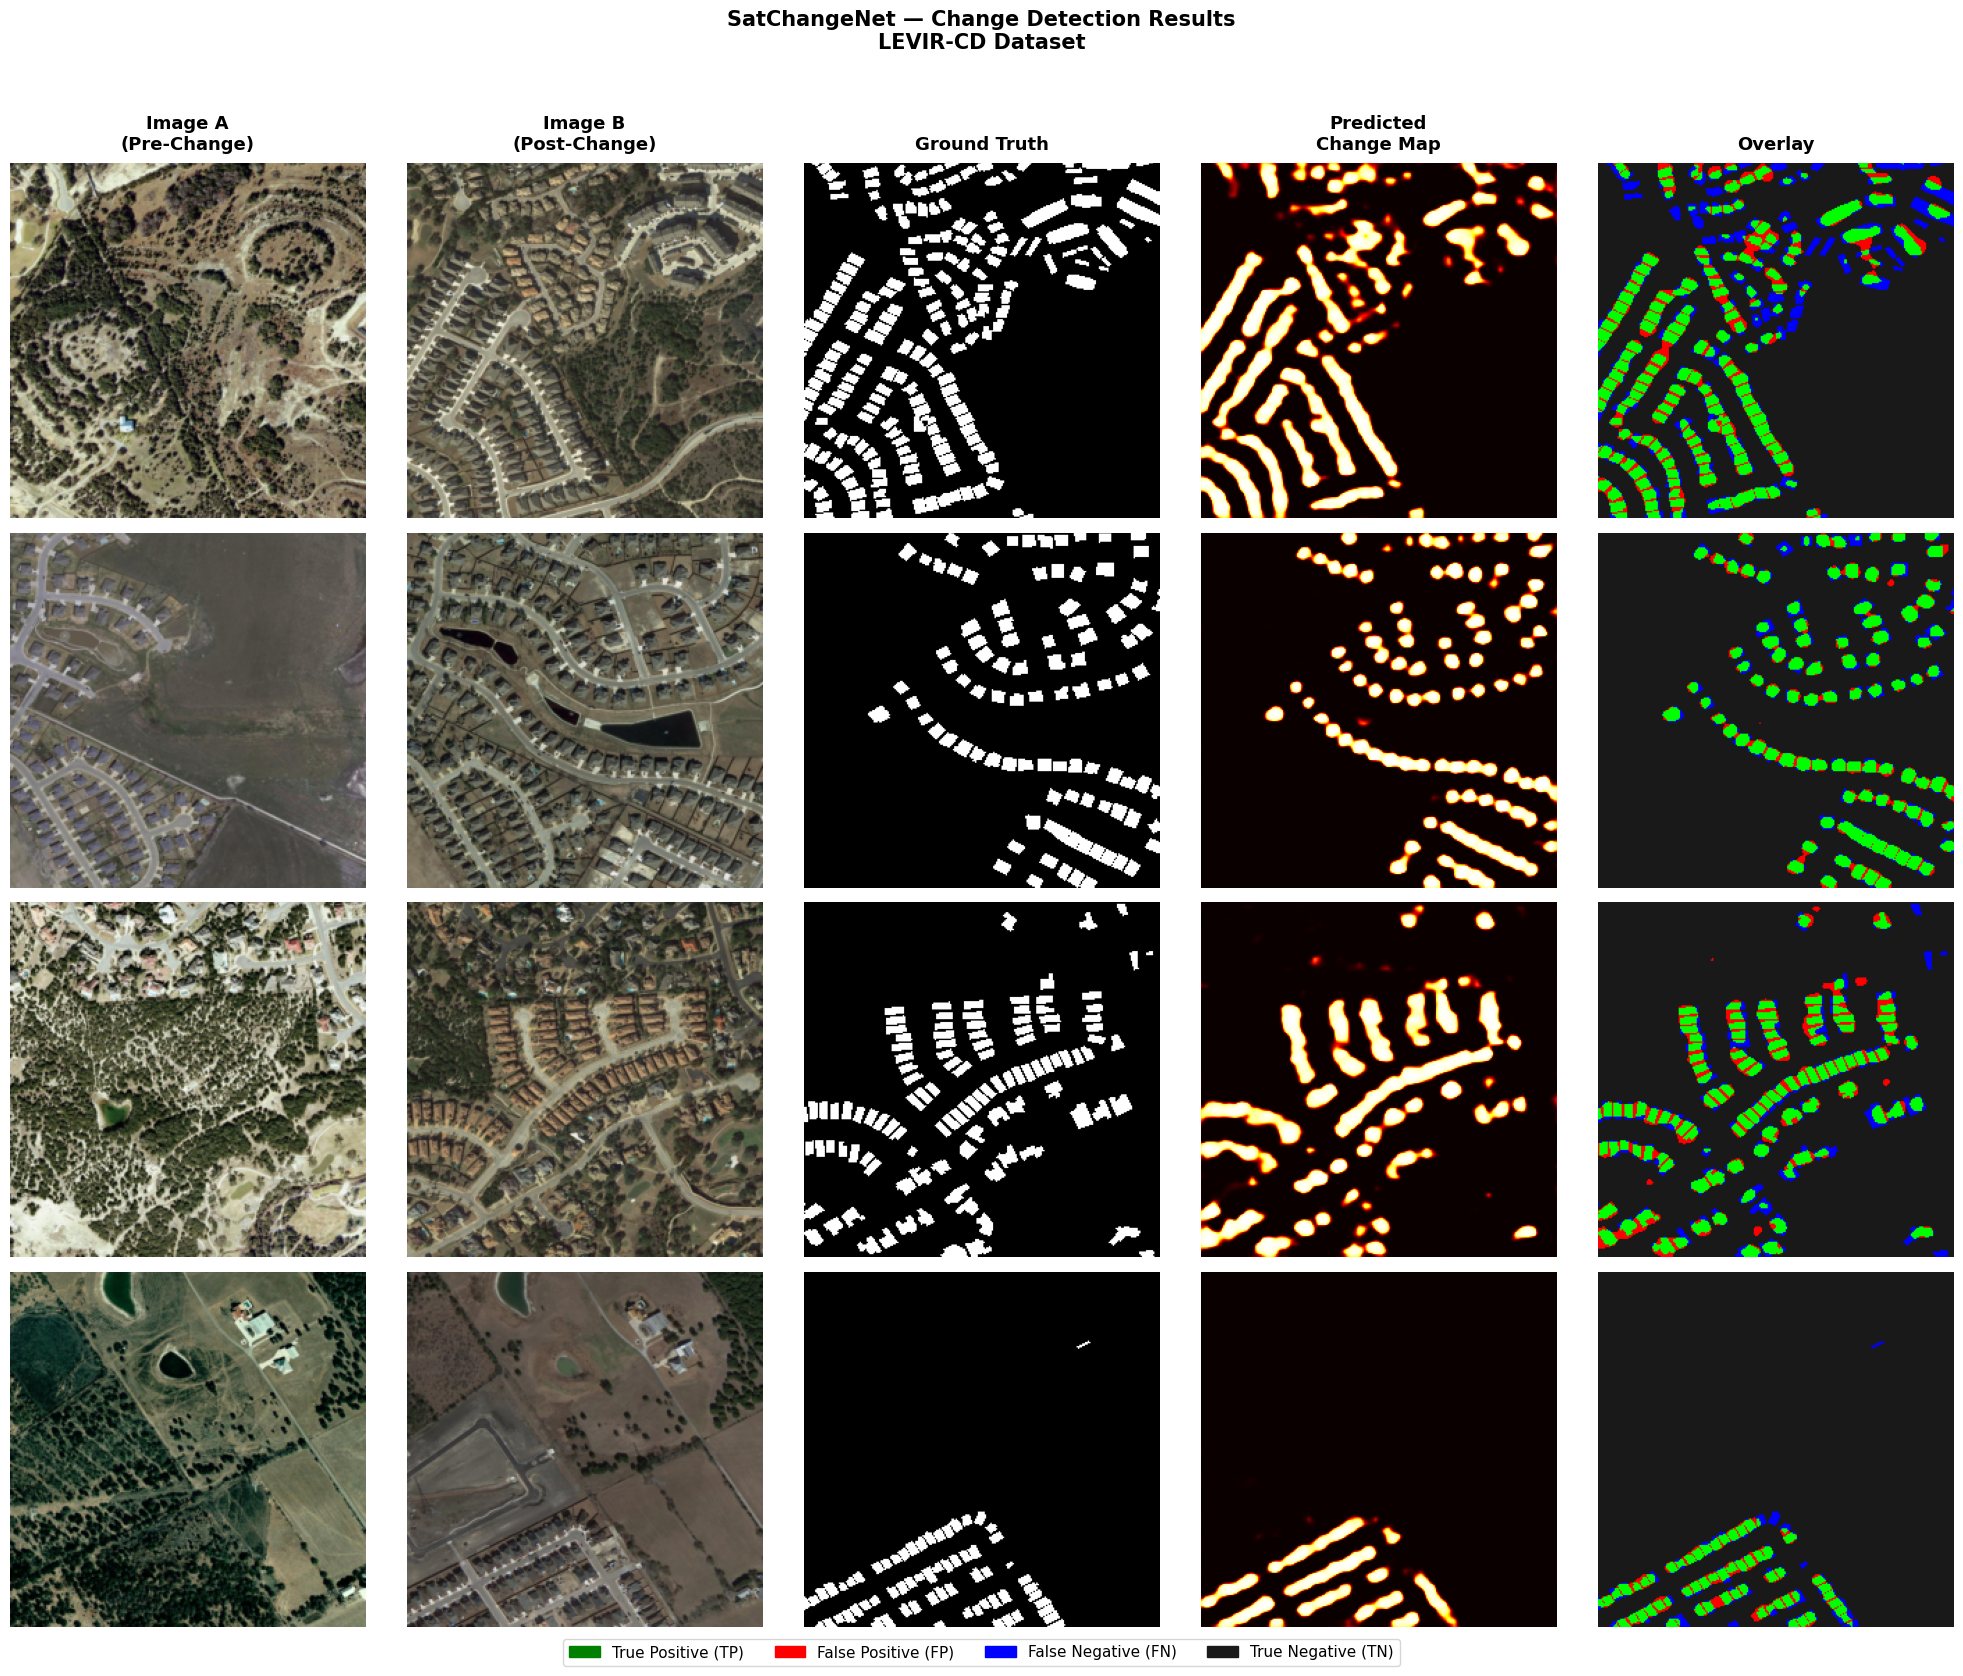

✅ Visualization saved to Google Drive!


In [20]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, dataset, device, num_samples=4, threshold=0.5):
    model.eval()

    # ── Denormalize helper ──
    def denormalize(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        return torch.clamp(tensor * std + mean, 0, 1)

    fig, axes = plt.subplots(num_samples, 5, figsize=(20, num_samples * 4))
    cols = ['Image A\n(Pre-Change)',
            'Image B\n(Post-Change)',
            'Ground Truth',
            'Predicted\nChange Map',
            'Overlay']

    # ── Column headers ──
    for ax, col in zip(axes[0], cols):
        ax.set_title(col, fontsize=13, fontweight='bold', pad=10)

    # ── Random samples ──
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    with torch.no_grad():
        for row, idx in enumerate(indices):
            img_A, img_B, label = dataset[idx]

            # Forward pass
            inp_A = img_A.unsqueeze(0).to(device)
            inp_B = img_B.unsqueeze(0).to(device)
            output = model(inp_A, inp_B)
            pred   = (torch.sigmoid(output) > threshold).float()

            # Convert to numpy
            img_A_show = denormalize(img_A).permute(1,2,0).numpy()
            img_B_show = denormalize(img_B).permute(1,2,0).numpy()
            label_show = label.squeeze(0).numpy()
            pred_show  = pred.squeeze().cpu().numpy()
            prob_show  = torch.sigmoid(output).squeeze().cpu().numpy()

            # ── Col 1: Image A ──
            axes[row,0].imshow(img_A_show)
            axes[row,0].axis('off')

            # ── Col 2: Image B ──
            axes[row,1].imshow(img_B_show)
            axes[row,1].axis('off')

            # ── Col 3: Ground Truth ──
            axes[row,2].imshow(label_show, cmap='gray')
            axes[row,2].axis('off')

            # ── Col 4: Predicted Change Map ──
            axes[row,3].imshow(prob_show, cmap='hot', vmin=0, vmax=1)
            axes[row,3].axis('off')

            # ── Col 5: Overlay (TP/FP/FN) ──
            overlay = np.zeros((*label_show.shape, 3))
            TP = (pred_show == 1) & (label_show == 1)
            FP = (pred_show == 1) & (label_show == 0)
            FN = (pred_show == 0) & (label_show == 1)
            TN = (pred_show == 0) & (label_show == 0)

            overlay[TN] = [0.1, 0.1, 0.1]   # Dark  = True Negative
            overlay[TP] = [0.0, 1.0, 0.0]   # Green = True Positive
            overlay[FP] = [1.0, 0.0, 0.0]   # Red   = False Positive
            overlay[FN] = [0.0, 0.0, 1.0]   # Blue  = False Negative

            axes[row,4].imshow(overlay)
            axes[row,4].axis('off')

            # ── Row label ──
            axes[row,0].set_ylabel(f'Sample {row+1}',
                                    fontsize=11,
                                    fontweight='bold',
                                    rotation=90,
                                    labelpad=10)

    # ── Legend ──
    legend = [
        mpatches.Patch(color='green', label='True Positive (TP)'),
        mpatches.Patch(color='red',   label='False Positive (FP)'),
        mpatches.Patch(color='blue',  label='False Negative (FN)'),
        mpatches.Patch(color='#1a1a1a', label='True Negative (TN)')
    ]
    fig.legend(handles=legend, loc='lower center',
               ncol=4, fontsize=11,
               bbox_to_anchor=(0.5, -0.02),
               frameon=True)

    plt.suptitle('SatChangeNet — Change Detection Results\nLEVIR-CD Dataset',
                  fontsize=15, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_sattlelite/results_visualization.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Visualization saved to Google Drive!")

# ── Run Visualization ────────────────────────────────
import matplotlib.patches as mpatches
visualize_predictions(model, test_dataset, DEVICE, num_samples=4)

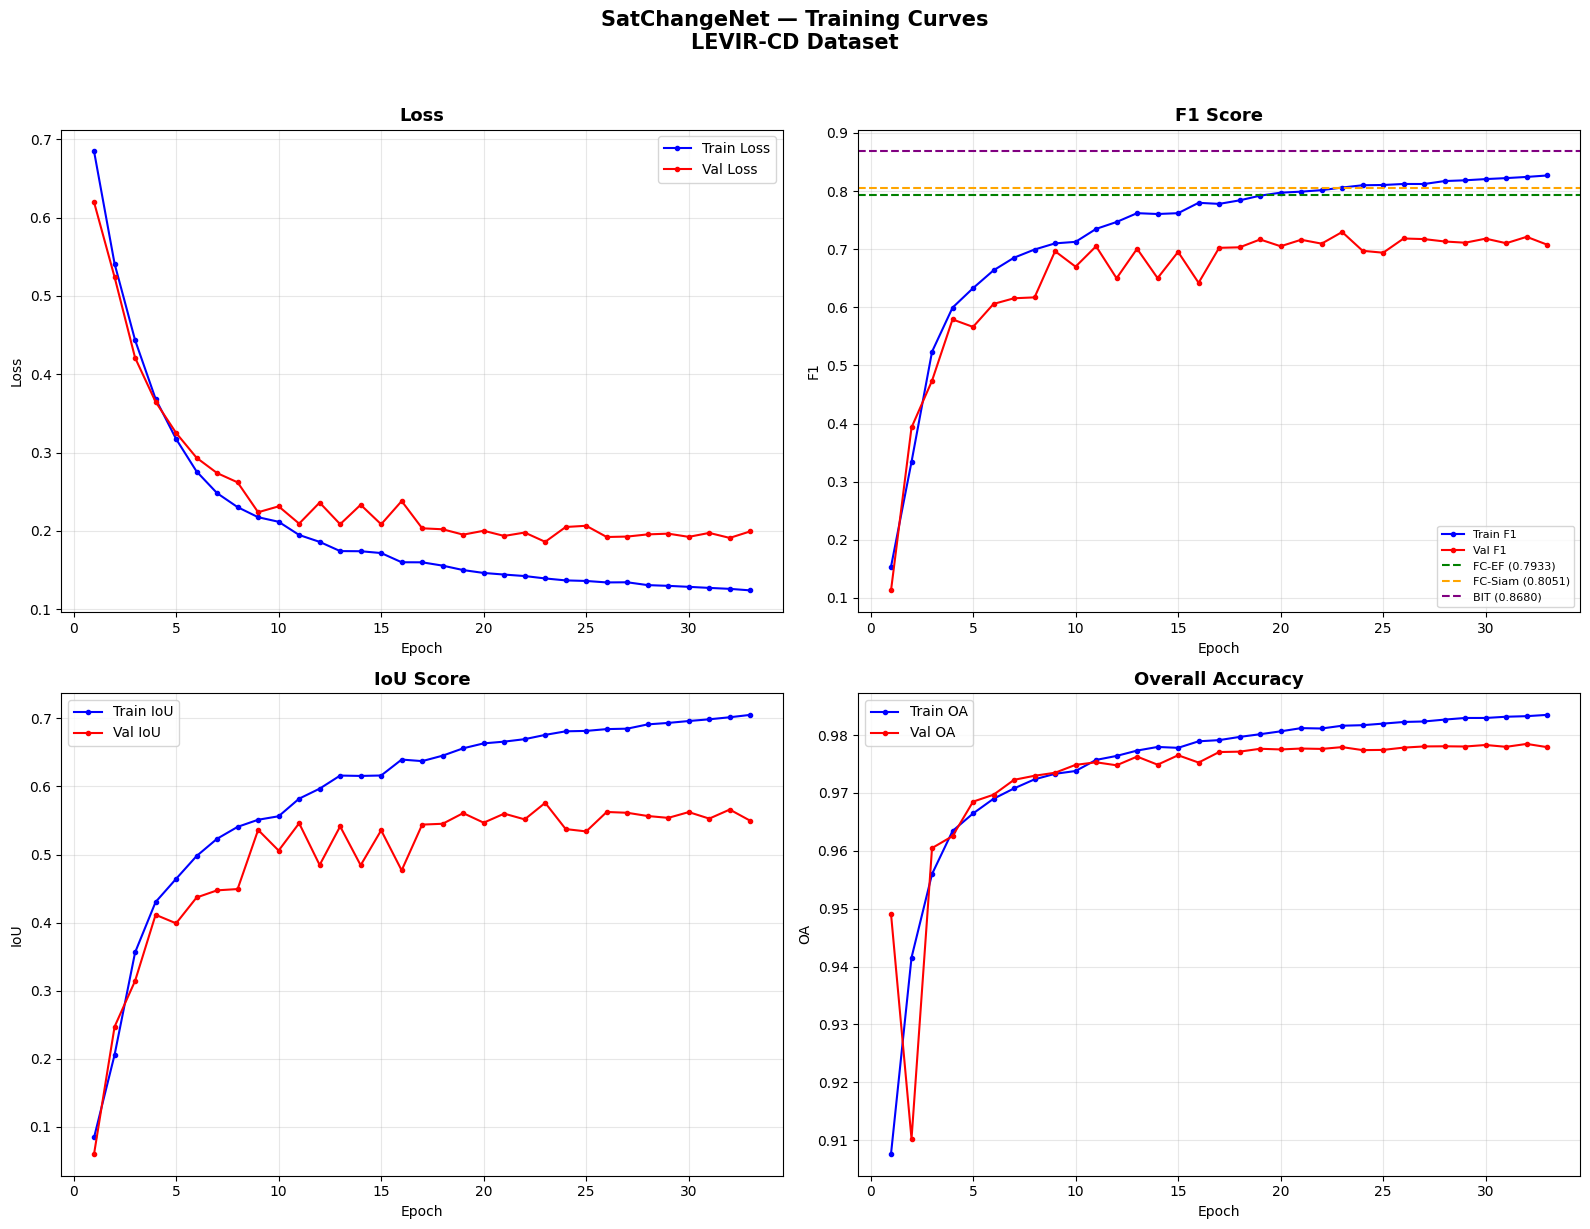

✅ Training curves saved to Google Drive!


In [21]:
def plot_training_curves(history):
    epochs     = [h['epoch']      for h in history]
    train_loss = [h['train_loss'] for h in history]
    val_loss   = [h['val_loss']   for h in history]
    train_f1   = [h['train_F1']   for h in history]
    val_f1     = [h['val_F1']     for h in history]
    train_iou  = [h['train_IoU']  for h in history]
    val_iou    = [h['val_IoU']    for h in history]
    train_oa   = [h['train_OA']   for h in history]
    val_oa     = [h['val_OA']     for h in history]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('SatChangeNet — Training Curves\nLEVIR-CD Dataset',
                  fontsize=15, fontweight='bold', y=1.02)

    # ── Plot 1: Loss ──
    axes[0,0].plot(epochs, train_loss, 'b-o', markersize=3, label='Train Loss')
    axes[0,0].plot(epochs, val_loss,   'r-o', markersize=3, label='Val Loss')
    axes[0,0].set_title('Loss',       fontsize=13, fontweight='bold')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # ── Plot 2: F1 ──
    axes[0,1].plot(epochs, train_f1, 'b-o', markersize=3, label='Train F1')
    axes[0,1].plot(epochs, val_f1,   'r-o', markersize=3, label='Val F1')
    axes[0,1].axhline(y=0.7933, color='g',      linestyle='--', label='FC-EF (0.7933)')
    axes[0,1].axhline(y=0.8051, color='orange',  linestyle='--', label='FC-Siam (0.8051)')
    axes[0,1].axhline(y=0.8680, color='purple',  linestyle='--', label='BIT (0.8680)')
    axes[0,1].set_title('F1 Score',  fontsize=13, fontweight='bold')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('F1')
    axes[0,1].legend(fontsize=8)
    axes[0,1].grid(True, alpha=0.3)

    # ── Plot 3: IoU ──
    axes[1,0].plot(epochs, train_iou, 'b-o', markersize=3, label='Train IoU')
    axes[1,0].plot(epochs, val_iou,   'r-o', markersize=3, label='Val IoU')
    axes[1,0].set_title('IoU Score', fontsize=13, fontweight='bold')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('IoU')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # ── Plot 4: OA ──
    axes[1,1].plot(epochs, train_oa, 'b-o', markersize=3, label='Train OA')
    axes[1,1].plot(epochs, val_oa,   'r-o', markersize=3, label='Val OA')
    axes[1,1].set_title('Overall Accuracy', fontsize=13, fontweight='bold')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('OA')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_sattlelite/training_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Training curves saved to Google Drive!")

# ── Run ──────────────────────────────────────────────
plot_training_curves(history)

📍 Using test sample index: 113

   SAMPLE #113 RESULTS
  F1        : 0.2204
  IoU       : 0.1239
  OA        : 0.9956
  TP        : 41
  FP        : 191
  FN        : 99
  TN        : 65,205
  Change %  : 0.35%


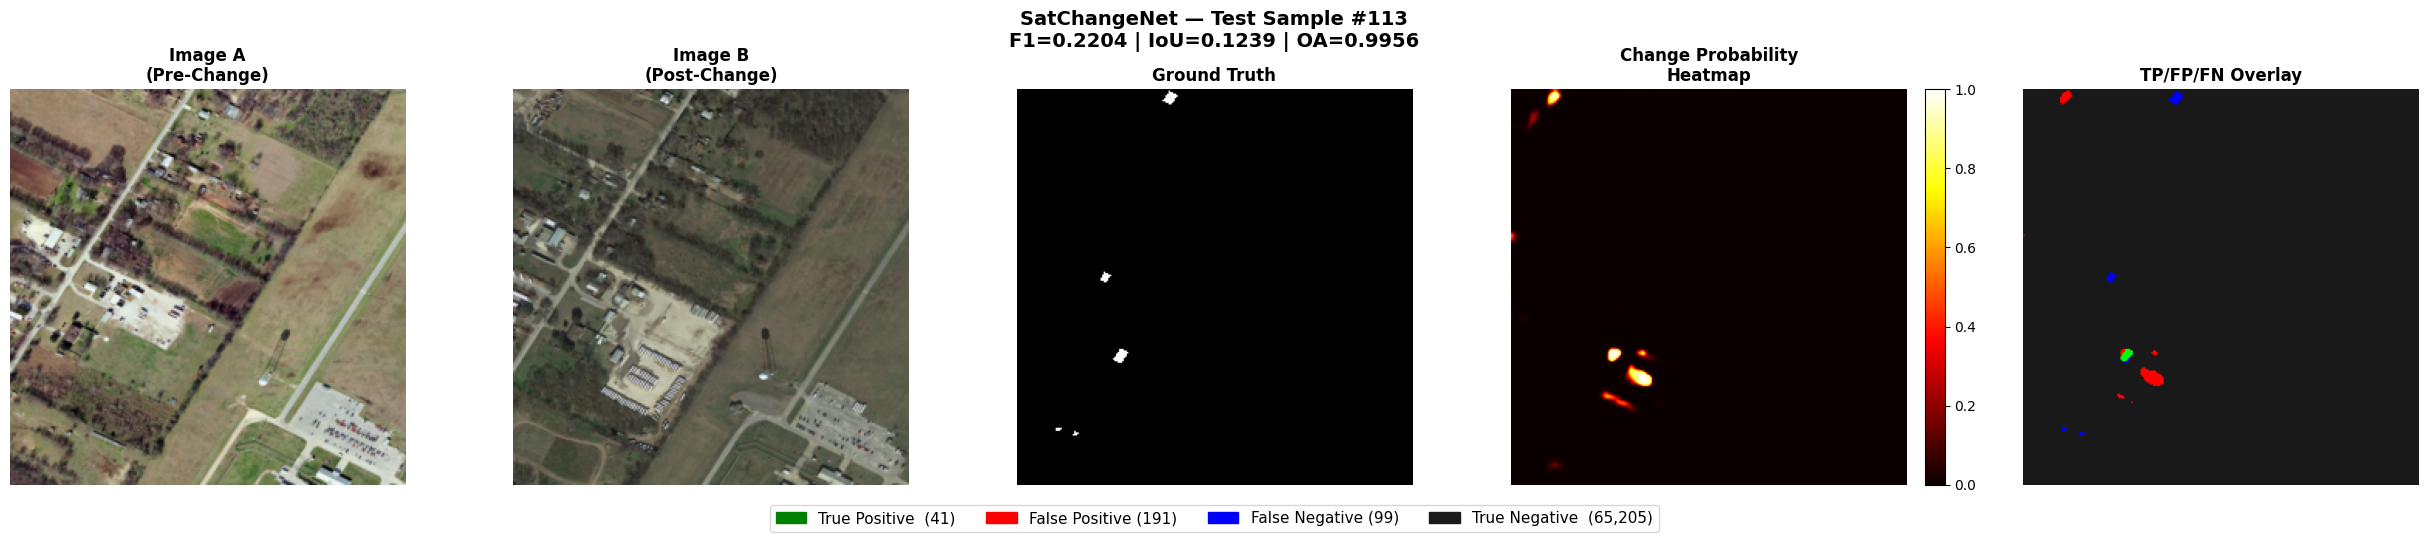

✅ Result saved to Google Drive!


In [22]:
def predict_from_test(model, dataset, device, idx=None, threshold=0.5):

    # ── Auto pick random if no idx given ─────────────
    if idx is None:
        idx = np.random.randint(0, len(dataset))

    print(f"📍 Using test sample index: {idx}")

    # ── Get sample ───────────────────────────────────
    img_A, img_B, label = dataset[idx]

    def denormalize(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        return torch.clamp(tensor * std + mean, 0, 1)

    # ── Inference ────────────────────────────────────
    model.eval()
    with torch.no_grad():
        inp_A  = img_A.unsqueeze(0).to(device)
        inp_B  = img_B.unsqueeze(0).to(device)
        output = model(inp_A, inp_B)
        prob   = torch.sigmoid(output).squeeze().cpu().numpy()
        pred   = (prob > threshold).astype(np.float32)

    # ── Convert to numpy ─────────────────────────────
    img_A_show  = denormalize(img_A).permute(1,2,0).numpy()
    img_B_show  = denormalize(img_B).permute(1,2,0).numpy()
    label_show  = label.squeeze(0).numpy()

    # ── Overlay (TP/FP/FN/TN) ────────────────────────
    overlay = np.zeros((*label_show.shape, 3))
    TP = (pred == 1) & (label_show == 1)
    FP = (pred == 1) & (label_show == 0)
    FN = (pred == 0) & (label_show == 1)
    TN = (pred == 0) & (label_show == 0)
    overlay[TN] = [0.1, 0.1, 0.1]
    overlay[TP] = [0.0, 1.0, 0.0]
    overlay[FP] = [1.0, 0.0, 0.0]
    overlay[FN] = [0.0, 0.0, 1.0]

    # ── Sample metrics ───────────────────────────────
    tp = TP.sum(); fp = FP.sum()
    fn = FN.sum(); tn = TN.sum()
    f1  = (2*tp) / (2*tp + fp + fn + 1e-6)
    iou = tp     / (tp + fp + fn + 1e-6)
    oa  = (tp+tn)/ (tp+tn+fp+fn + 1e-6)

    # ── Plot ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(f'SatChangeNet — Test Sample #{idx}\nF1={f1:.4f} | IoU={iou:.4f} | OA={oa:.4f}',
                  fontsize=14, fontweight='bold')

    axes[0].imshow(img_A_show)
    axes[0].set_title('Image A\n(Pre-Change)',  fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(img_B_show)
    axes[1].set_title('Image B\n(Post-Change)', fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(label_show, cmap='gray')
    axes[2].set_title('Ground Truth',           fontweight='bold')
    axes[2].axis('off')

    heatmap = axes[3].imshow(prob, cmap='hot', vmin=0, vmax=1)
    axes[3].set_title('Change Probability\nHeatmap', fontweight='bold')
    axes[3].axis('off')
    plt.colorbar(heatmap, ax=axes[3], fraction=0.046, pad=0.04)

    axes[4].imshow(overlay)
    axes[4].set_title('TP/FP/FN Overlay',       fontweight='bold')
    axes[4].axis('off')

    # ── Legend ───────────────────────────────────────
    legend = [
        mpatches.Patch(color='green',   label=f'True Positive  ({tp:,})'),
        mpatches.Patch(color='red',     label=f'False Positive ({fp:,})'),
        mpatches.Patch(color='blue',    label=f'False Negative ({fn:,})'),
        mpatches.Patch(color='#1a1a1a', label=f'True Negative  ({tn:,})')
    ]
    fig.legend(handles=legend, loc='lower center',
               ncol=4, fontsize=11,
               bbox_to_anchor=(0.5, -0.08),
               frameon=True)

    print("\n" + "="*40)
    print(f"   SAMPLE #{idx} RESULTS")
    print("="*40)
    print(f"  F1        : {f1:.4f}")
    print(f"  IoU       : {iou:.4f}")
    print(f"  OA        : {oa:.4f}")
    print(f"  TP        : {tp:,}")
    print(f"  FP        : {fp:,}")
    print(f"  FN        : {fn:,}")
    print(f"  TN        : {tn:,}")
    print(f"  Change %  : {(pred.sum()/pred.size)*100:.2f}%")
    print("="*40)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_sattlelite/sample_inference.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Result saved to Google Drive!")

# ── Run — change idx to any number 0-127 ─────────────
predict_from_test(model, test_dataset, DEVICE, idx=None)

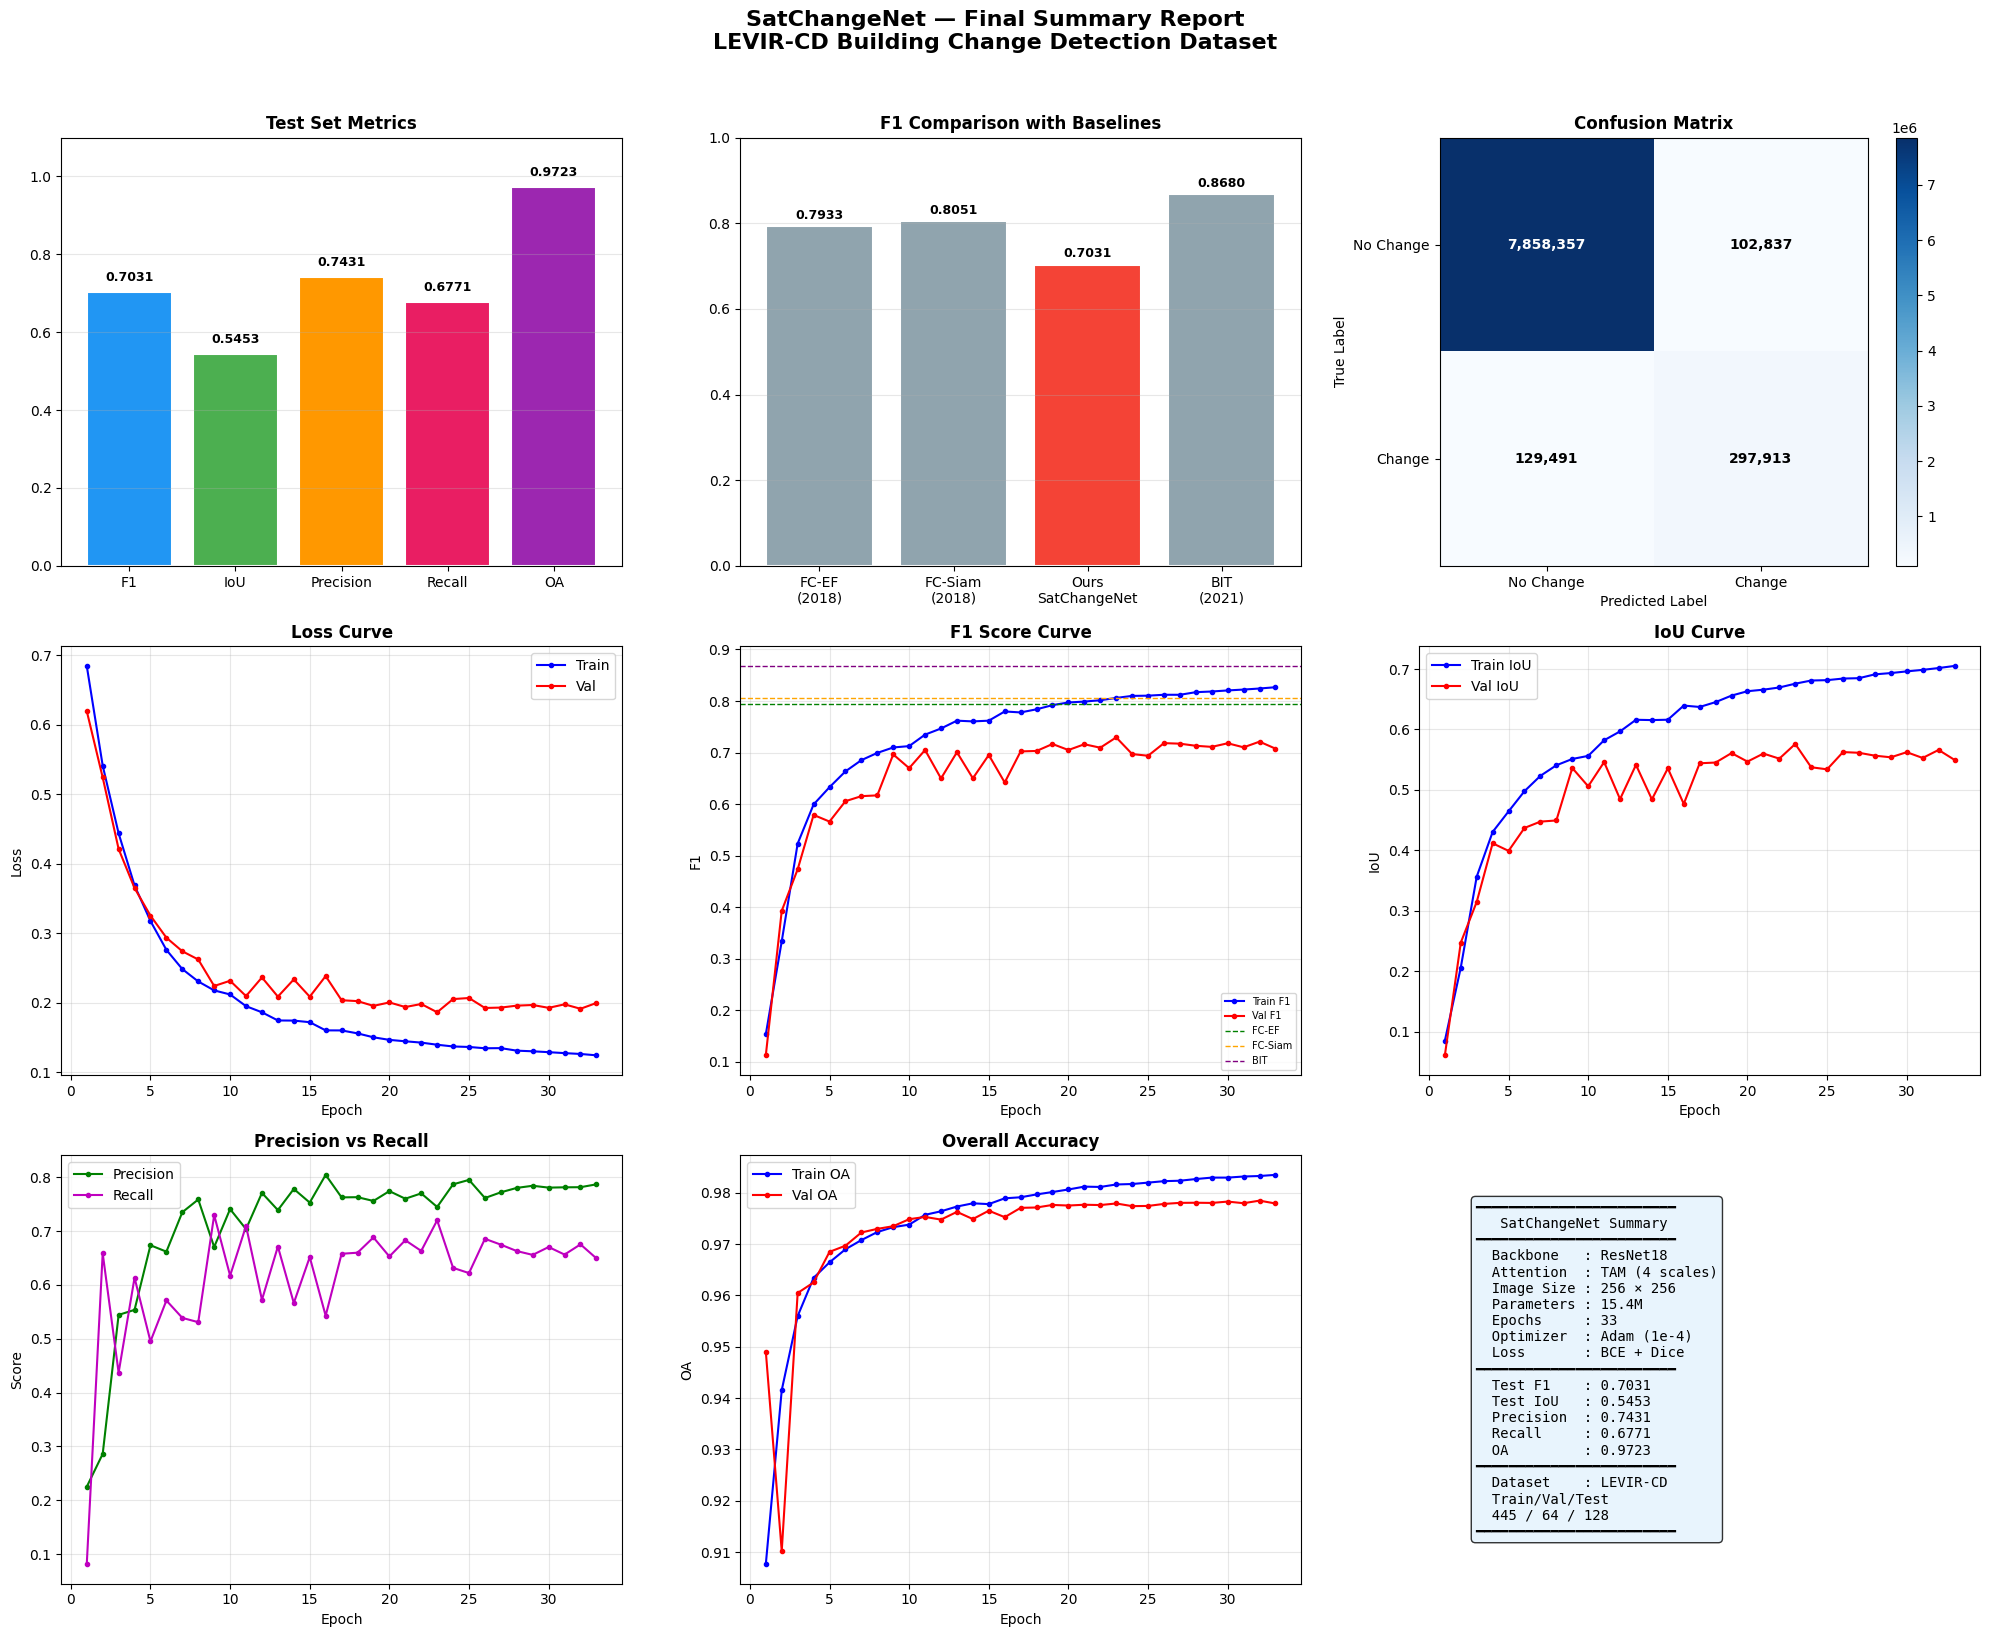

✅ Final summary saved to Google Drive!


In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_final_summary(test_metrics, history):

    fig = plt.figure(figsize=(20, 16))
    fig.suptitle('SatChangeNet — Final Summary Report\nLEVIR-CD Building Change Detection Dataset',
                  fontsize=16, fontweight='bold', y=1.02)

    # ══════════════════════════════════════════════════
    # Plot 1: Final Metrics Bar Chart
    # ══════════════════════════════════════════════════
    ax1 = fig.add_subplot(3, 3, 1)
    metrics_names  = ['F1', 'IoU', 'Precision', 'Recall', 'OA']
    metrics_values = [
        test_metrics['F1'],
        test_metrics['IoU'],
        test_metrics['Precision'],
        test_metrics['Recall'],
        test_metrics['OA']
    ]
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
    bars   = ax1.bar(metrics_names, metrics_values, color=colors, edgecolor='white', linewidth=1.5)
    ax1.set_title('Test Set Metrics', fontweight='bold', fontsize=12)
    ax1.set_ylim(0, 1.1)
    ax1.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, metrics_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                  f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    # ══════════════════════════════════════════════════
    # Plot 2: Baseline Comparison Bar Chart
    # ══════════════════════════════════════════════════
    ax2 = fig.add_subplot(3, 3, 2)
    models  = ['FC-EF\n(2018)', 'FC-Siam\n(2018)', 'Ours\nSatChangeNet', 'BIT\n(2021)']
    f1s     = [0.7933,          0.8051,              test_metrics['F1'],   0.8680]
    colors2 = ['#90A4AE',       '#90A4AE',            '#F44336',            '#90A4AE']
    bars2   = ax2.bar(models, f1s, color=colors2, edgecolor='white', linewidth=1.5)
    ax2.set_title('F1 Comparison with Baselines', fontweight='bold', fontsize=12)
    ax2.set_ylim(0, 1.0)
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars2, f1s):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

    # ══════════════════════════════════════════════════
    # Plot 3: Confusion Matrix
    # ══════════════════════════════════════════════════
    ax3  = fig.add_subplot(3, 3, 3)
    model.eval()
    all_preds   = []
    all_targets = []
    with torch.no_grad():
        for img_A, img_B, label in test_loader:
            img_A, img_B = img_A.to(DEVICE), img_B.to(DEVICE)
            output = model(img_A, img_B)
            pred   = (torch.sigmoid(output) > 0.5).float()
            all_preds.append(pred.cpu().view(-1))
            all_targets.append(label.view(-1))

    all_preds   = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    TP = ((all_preds == 1) & (all_targets == 1)).sum()
    TN = ((all_preds == 0) & (all_targets == 0)).sum()
    FP = ((all_preds == 1) & (all_targets == 0)).sum()
    FN = ((all_preds == 0) & (all_targets == 1)).sum()

    cm = np.array([[TN, FP], [FN, TP]])
    im = ax3.imshow(cm, interpolation='nearest', cmap='Blues')
    ax3.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Predicted Label')
    ax3.set_ylabel('True Label')
    ax3.set_xticks([0, 1]); ax3.set_xticklabels(['No Change', 'Change'])
    ax3.set_yticks([0, 1]); ax3.set_yticklabels(['No Change', 'Change'])
    plt.colorbar(im, ax=ax3)
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax3.text(j, i, f'{cm[i,j]:,}',
                      ha='center', va='center', fontsize=10, fontweight='bold',
                      color='white' if cm[i,j] > thresh else 'black')

    # ══════════════════════════════════════════════════
    # Plot 4: Loss Curve
    # ══════════════════════════════════════════════════
    ax4    = fig.add_subplot(3, 3, 4)
    epochs = [h['epoch']      for h in history]
    ax4.plot(epochs, [h['train_loss'] for h in history], 'b-o', markersize=3, label='Train')
    ax4.plot(epochs, [h['val_loss']   for h in history], 'r-o', markersize=3, label='Val')
    ax4.set_title('Loss Curve', fontweight='bold', fontsize=12)
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Loss')
    ax4.legend(); ax4.grid(True, alpha=0.3)

    # ══════════════════════════════════════════════════
    # Plot 5: F1 Curve
    # ══════════════════════════════════════════════════
    ax5 = fig.add_subplot(3, 3, 5)
    ax5.plot(epochs, [h['train_F1'] for h in history], 'b-o', markersize=3, label='Train F1')
    ax5.plot(epochs, [h['val_F1']   for h in history], 'r-o', markersize=3, label='Val F1')
    ax5.axhline(y=0.7933, color='g',      linestyle='--', linewidth=1, label='FC-EF')
    ax5.axhline(y=0.8051, color='orange', linestyle='--', linewidth=1, label='FC-Siam')
    ax5.axhline(y=0.8680, color='purple', linestyle='--', linewidth=1, label='BIT')
    ax5.set_title('F1 Score Curve', fontweight='bold', fontsize=12)
    ax5.set_xlabel('Epoch'); ax5.set_ylabel('F1')
    ax5.legend(fontsize=7); ax5.grid(True, alpha=0.3)

    # ══════════════════════════════════════════════════
    # Plot 6: IoU Curve
    # ══════════════════════════════════════════════════
    ax6 = fig.add_subplot(3, 3, 6)
    ax6.plot(epochs, [h['train_IoU'] for h in history], 'b-o', markersize=3, label='Train IoU')
    ax6.plot(epochs, [h['val_IoU']   for h in history], 'r-o', markersize=3, label='Val IoU')
    ax6.set_title('IoU Curve', fontweight='bold', fontsize=12)
    ax6.set_xlabel('Epoch'); ax6.set_ylabel('IoU')
    ax6.legend(); ax6.grid(True, alpha=0.3)

    # ══════════════════════════════════════════════════
    # Plot 7: Precision vs Recall Curve
    # ══════════════════════════════════════════════════
    ax7 = fig.add_subplot(3, 3, 7)
    ax7.plot(epochs, [h['val_Precision'] for h in history], 'g-o', markersize=3, label='Precision')
    ax7.plot(epochs, [h['val_Recall']    for h in history], 'm-o', markersize=3, label='Recall')
    ax7.set_title('Precision vs Recall', fontweight='bold', fontsize=12)
    ax7.set_xlabel('Epoch'); ax7.set_ylabel('Score')
    ax7.legend(); ax7.grid(True, alpha=0.3)

    # ══════════════════════════════════════════════════
    # Plot 8: OA Curve
    # ══════════════════════════════════════════════════
    ax8 = fig.add_subplot(3, 3, 8)
    ax8.plot(epochs, [h['train_OA'] for h in history], 'b-o', markersize=3, label='Train OA')
    ax8.plot(epochs, [h['val_OA']   for h in history], 'r-o', markersize=3, label='Val OA')
    ax8.set_title('Overall Accuracy', fontweight='bold', fontsize=12)
    ax8.set_xlabel('Epoch'); ax8.set_ylabel('OA')
    ax8.legend(); ax8.grid(True, alpha=0.3)

    # ══════════════════════════════════════════════════
    # Plot 9: Final Summary Text Box
    # ══════════════════════════════════════════════════
    ax9 = fig.add_subplot(3, 3, 9)
    ax9.axis('off')
    summary_text = (
        "━━━━━━━━━━━━━━━━━━━━━━━━\n"
        "   SatChangeNet Summary\n"
        "━━━━━━━━━━━━━━━━━━━━━━━━\n"
        f"  Backbone   : ResNet18\n"
        f"  Attention  : TAM (4 scales)\n"
        f"  Image Size : 256 × 256\n"
        f"  Parameters : 15.4M\n"
        f"  Epochs     : {len(history)}\n"
        f"  Optimizer  : Adam (1e-4)\n"
        f"  Loss       : BCE + Dice\n"
        "━━━━━━━━━━━━━━━━━━━━━━━━\n"
        f"  Test F1    : {test_metrics['F1']:.4f}\n"
        f"  Test IoU   : {test_metrics['IoU']:.4f}\n"
        f"  Precision  : {test_metrics['Precision']:.4f}\n"
        f"  Recall     : {test_metrics['Recall']:.4f}\n"
        f"  OA         : {test_metrics['OA']:.4f}\n"
        "━━━━━━━━━━━━━━━━━━━━━━━━\n"
        f"  Dataset    : LEVIR-CD\n"
        f"  Train/Val/Test\n"
        f"  445 / 64 / 128\n"
        "━━━━━━━━━━━━━━━━━━━━━━━━"
    )
    ax9.text(0.1, 0.5, summary_text,
              transform=ax9.transAxes,
              fontsize=10, verticalalignment='center',
              fontfamily='monospace',
              bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=0.8))

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/project_sattlelite/final_summary.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Final summary saved to Google Drive!")

# ── Run ──────────────────────────────────────────────
plot_final_summary(test_metrics, history)

In [24]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Total parameters (M): {total_params / 1e6:.2f} M")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable parameters (M): {trainable_params / 1e6:.2f} M")

Total parameters: 15,403,989
Total parameters (M): 15.40 M
Trainable parameters: 15,403,989
Trainable parameters (M): 15.40 M


In [25]:
!pip install -q thop

In [26]:
from thop import profile

model.eval()

dummy_A = torch.randn(1, 3, 256, 256).to(DEVICE)
dummy_B = torch.randn(1, 3, 256, 256).to(DEVICE)

flops, params = profile(
    model,
    inputs=(dummy_A, dummy_B),
    verbose=False
)

print(f"FLOPs: {flops:,}")
print(f"GFLOPs: {flops / 1e9:.2f}")
print(f"Parameters from THOP: {params:,}")
print(f"Parameters from THOP (M): {params / 1e6:.2f}")

FLOPs: 5,887,496,768.0
GFLOPs: 5.89
Parameters from THOP: 15,403,985.0
Parameters from THOP (M): 15.40


In [27]:
import time
import torch

model.eval()

# Create one pair of 256x256 images
dummy_A = torch.randn(1, 3, 256, 256).to(DEVICE)
dummy_B = torch.randn(1, 3, 256, 256).to(DEVICE)

# -----------------------------
# Warm-up
# -----------------------------
with torch.no_grad():
    for _ in range(20):
        _ = model(dummy_A, dummy_B)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

# -----------------------------
# Actual measurement
# -----------------------------
num_runs = 100

start = time.perf_counter()

with torch.no_grad():
    for _ in range(num_runs):
        _ = model(dummy_A, dummy_B)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

end = time.perf_counter()

total_time = end - start
avg_time = total_time / num_runs

print(f"Total time for {num_runs} runs : {total_time:.4f} seconds")
print(f"Average inference time        : {avg_time * 1000:.2f} ms")
print(f"Inference time per image pair : {avg_time * 1000:.2f} ms")
print(f"FPS                           : {1 / avg_time:.2f}")

Total time for 100 runs : 2.9496 seconds
Average inference time        : 29.50 ms
Inference time per image pair : 29.50 ms
FPS                           : 33.90
